# Clustering of TOP 5 European Leagues Players - 2022/23
**Authors:** Cezary Kuźmowicz, Filip Żebrowski, Dariusz Doktorski

This notebook extends the 2021/22 reproduction analysis to the 2022/23 season. We proceed the same way as before: use the same feature set, preprocessing rules, clustering method, and evaluation plots, but load the newer season data.

[dataset used for analysis](https://www.kaggle.com/datasets/vivovinco/20222023-football-player-stats)

In [18]:
from IPython.display import display

from football_clustering import (
    AnalysisConfig,
    add_cluster_labels,
    add_pca_components,
    cluster_feature_means,
    configure_notebook,
    evaluate_clusters,
    filter_by_minutes,
    fit_kmeans,
    hopkins_statistic,
    load_player_stats,
    plot_cluster_evaluation,
    plot_correlation_matrix,
    plot_distributions,
    plot_pca_clusters,
    plot_silhouette_profile,
    prepare_visualization_data,
    scale_features,
    select_features,
    validate_no_missing_values,
)

## Setup
Only the input file changes here. The shared configuration defaults and reusable analysis functions are defined in `football_clustering.py`.

In [19]:
FILE_PATH = "data/2022-2023 Football Player Stats.csv"

config = AnalysisConfig(file_path=FILE_PATH)

SELECTED_FEATURES = list(config.selected_features)
VISUALIZATION_FEATURES = list(config.visualization_features)

configure_notebook(config.random_seed)

## Data Preparation
We load the 2022/23 data and apply the same minimum-minutes filter used in the first analysis.

In [20]:
# Load the dataset using shared CSV formatting parameters.
raw_stats = load_player_stats(config)

In [21]:
# Filter players based on the configured minimum minutes played.
stats_filtered = filter_by_minutes(raw_stats, config.min_minutes_played)

In [22]:
display(stats_filtered.head())
display(stats_filtered.describe())
print(stats_filtered.info())

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
0,1,Brenden Aaronson,USA,MFFW,Leeds United,Premier League,22,2000,20,19,...,0.17,2.54,0.51,0.0,0.0,0.00,4.86,0.34,1.19,22.2
1,2,Yunis Abdelhamid,MAR,DF,Reims,Ligue 1,35,1987,22,22,...,0.05,0.18,1.59,0.0,0.0,0.00,6.64,2.18,1.23,64.0
2,3,Himad Abdelli,FRA,MFFW,Angers,Ligue 1,23,1999,14,8,...,0.00,1.05,1.40,0.0,0.0,0.00,8.14,0.93,1.05,47.1
3,4,Salis Abdul Samed,GHA,MF,Lens,Ligue 1,22,2000,20,20,...,0.00,0.35,0.80,0.0,0.0,0.05,6.60,0.50,0.50,50.0
4,5,Laurent Abergel,FRA,MF,Lorient,Ligue 1,30,1993,15,15,...,0.00,0.23,2.02,0.0,0.0,0.00,6.51,0.31,0.39,44.4


,Rk,Age,Born,MP,Starts,Min,90s,Goals,Shots,SoT,...,Off,Crs,TklW,PKwon,PKcon,OG,Recov,AerWon,AerLost,AerWon%
count,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,...,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000,2061.000000
mean,1337.290150,26.601164,1995.567686,14.580786,10.917031,971.866570,10.799272,1.320233,1.202077,0.397351,...,0.188326,1.594289,0.921121,0.011664,0.015803,0.004100,4.890112,1.285939,1.348559,48.143183
std,772.673299,4.240017,4.250175,5.252729,6.178840,513.420707,5.704756,2.214323,1.007596,0.427438,...,0.316761,1.913114,0.601791,0.046284,0.050258,0.025748,1.926001,1.168281,1.111843,21.472312
min,1.000000,16.000000,1981.000000,2.000000,0.000000,180.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,679.000000,23.000000,1993.000000,11.000000,5.000000,521.000000,5.800000,0.000000,0.410000,0.050000,...,0.000000,0.170000,0.490000,0.000000,0.000000,0.000000,3.720000,0.480000,0.670000,33.300000
50%,1329.000000,26.000000,1996.000000,16.000000,11.000000,954.000000,10.600000,0.000000,0.930000,0.270000,...,0.050000,0.860000,0.880000,0.000000,0.000000,0.000000,5.050000,1.000000,1.110000,50.000000
75%,2000.000000,30.000000,1999.000000,19.000000,16.000000,1393.000000,15.500000,2.000000,1.820000,0.630000,...,0.250000,2.420000,1.290000,0.000000,0.000000,0.000000,6.170000,1.780000,1.710000,60.600000
max,2689.000000,41.000000,2006.000000,23.000000,23.000000,2070.000000,23.000000,25.000000,5.550000,2.500000,...,2.800000,11.300000,4.000000,0.870000,0.480000,0.500000,11.300000,14.500000,9.400000,100.000000


<class 'pandas.core.frame.DataFrame'>
Index: 2061 entries, 0 to 2688
Columns: 124 entries, Rk to AerWon%
dtypes: float64(112), int64(7), object(5)
memory usage: 2.0+ MB
None


We also keep the same missing value validation step before clustering.

In [23]:
# Print variables with missing values (if any) and fail before clustering if any exist.
missing_vals = validate_no_missing_values(stats_filtered)
print(missing_vals)
print("Data validation passed: No missing values found.")

Series([], dtype: int64)
Data validation passed: No missing values found.


## Feature Selection
The same eight clustering variables selected in the 2021/22 notebook are reused here, so the seasons can be compared under the same assumptions.

In [24]:
reduced_stats = select_features(stats_filtered, SELECTED_FEATURES)
reduced_stats.head()

,Shots,PasTotAtt,Assists,Tkl,Blocks,Fls,Off,AerWon%
0,1.53,31.0,0.11,1.64,1.69,0.62,0.17,22.2
1,0.86,47.2,0.05,2.50,2.23,1.32,0.05,64.0
2,1.05,49.5,0.00,2.91,1.51,1.74,0.00,47.1
3,0.60,64.9,0.00,1.50,1.30,2.45,0.00,50.0
4,0.31,43.4,0.08,3.80,1.40,0.93,0.00,44.4


## Clusterability Check
As before, Hopkins statistic is used as a quick check that the selected feature space has clustering tendency.

In [25]:
hopkins_val = hopkins_statistic(
    reduced_stats,
    sample_ratio=config.hopkins_sample_ratio,
    n_neighbors=config.hopkins_n_neighbors,
)
print(f"Hopkins Statistic: {hopkins_val:.4f}")

Hopkins Statistic: 0.8270


## Quick Visual Checks
The following plots repeat the same exploratory checks from the original notebook. The source CSVs use different `Goals` conventions: 2021/22 stores goals per 90, while 2022/23 stores total goals. The shared helper normalizes this before plotting `Distribution of Goals`, so this chart is comparable across seasons.

In [26]:
player_stats = prepare_visualization_data(stats_filtered, VISUALIZATION_FEATURES)

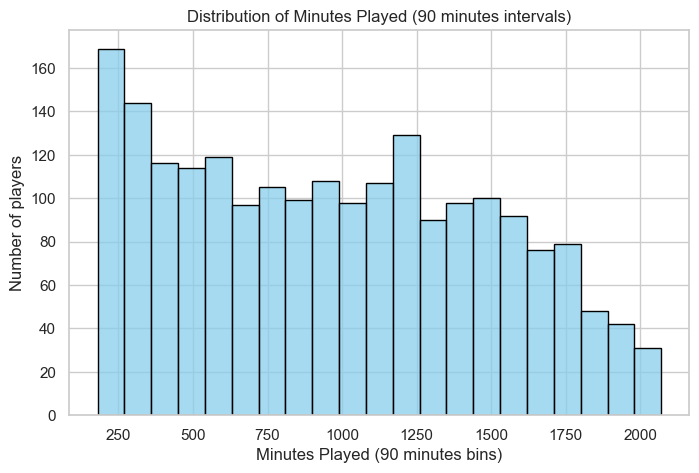

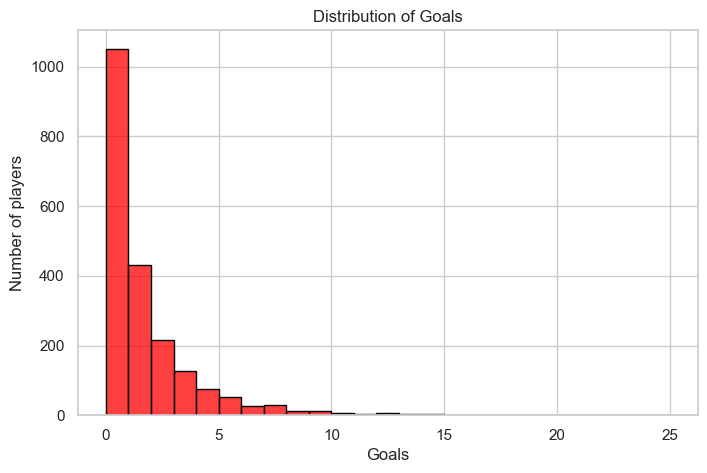

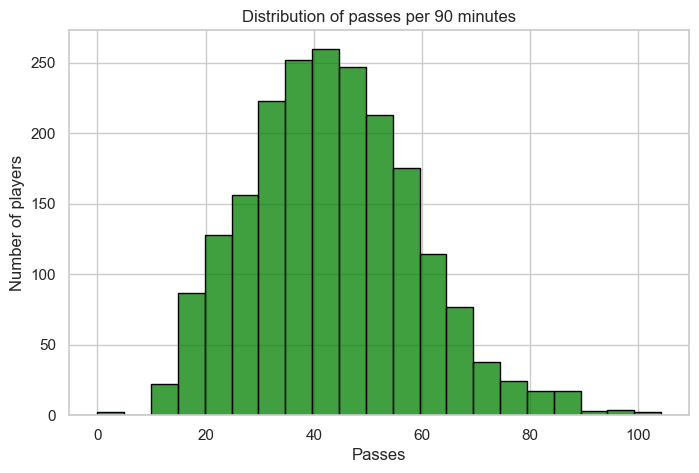

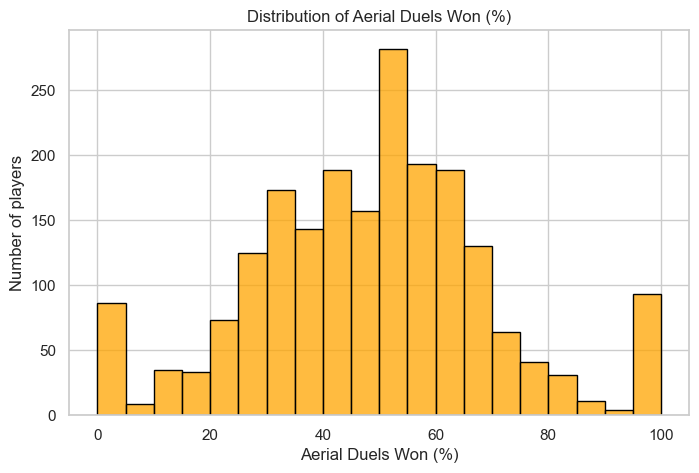

In [27]:
plot_distributions(player_stats)

The correlation matrix is retained to verify that the reused feature set is still reasonable for the newer season.

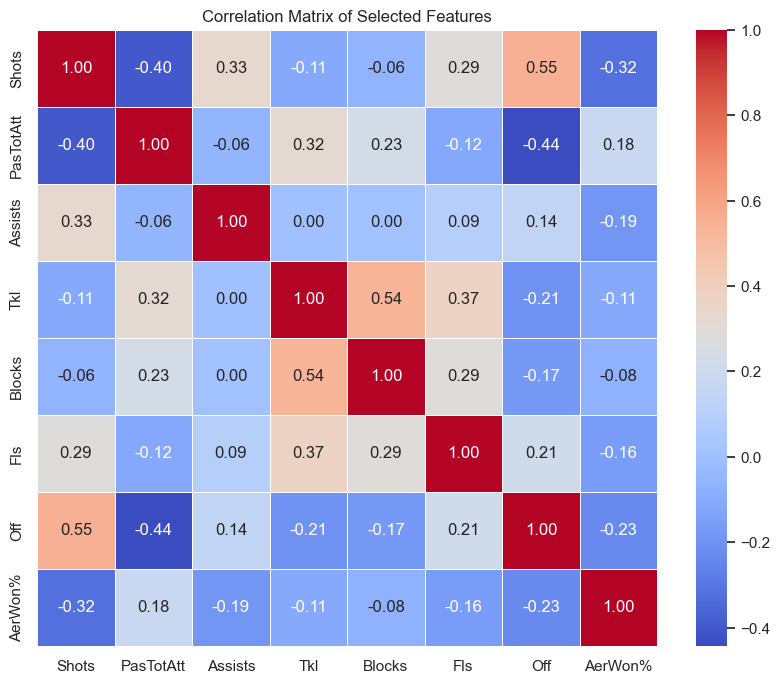

In [28]:
plot_correlation_matrix(reduced_stats, "Correlation Matrix of Selected Features")

## Clustering
We standardize the selected features and compare candidate numbers of clusters. The silhouette check is used to identify the best standalone `k` for 2022/23, while the final model below still uses `k = 3` to keep the cluster interpretation comparable with the 2021/22 reproduction.

In [29]:
stats_scaled, scaler = scale_features(reduced_stats, SELECTED_FEATURES)

display(stats_scaled.head())
display(stats_scaled.describe().round(2))

,Shots,PasTotAtt,Assists,Tkl,Blocks,Fls,Off,AerWon%
0,0.325530,-0.804912,0.175373,0.048020,1.136233,-0.791275,-0.057869,-1.208509
1,-0.339580,0.241467,-0.277187,0.938334,2.073019,0.203698,-0.436796,0.738657
2,-0.150967,0.390026,-0.654320,1.362786,0.823970,0.800682,-0.594682,-0.048594
3,-0.597683,1.384732,-0.654320,-0.096915,0.459665,1.809869,-0.594682,0.086496
4,-0.885566,-0.003980,-0.050907,2.284157,0.633144,-0.350644,-0.594682,-0.174368


,Shots,PasTotAtt,Assists,Tkl,Blocks,Fls,Off,AerWon%
count,2061.00,2061.00,2061.00,2061.00,2061.00,2061.00,2061.00,2061.00
mean,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.19,-2.81,-0.65,-1.65,-1.80,-1.67,-0.59,-2.24
25%,-0.79,-0.72,-0.65,-0.70,-0.60,-0.66,-0.59,-0.69
50%,-0.27,-0.06,-0.65,-0.06,-0.03,-0.09,-0.44,0.09
75%,0.61,0.64,0.40,0.62,0.60,0.56,0.19,0.58
max,4.32,3.92,8.02,4.56,4.81,5.12,8.25,2.42


Best k by silhouette for 2022/23: 2


,k,wcss,silhouette_score
0,2,12897.0185,0.2540
1,3,10900.8173,0.2331
2,4,9874.9045,0.1890
3,5,8938.5547,0.1907
4,6,8205.8495,0.1942
5,7,7800.3536,0.1878
6,8,7446.8580,0.1786
7,9,7115.1739,0.1649
8,10,6876.8443,0.1681


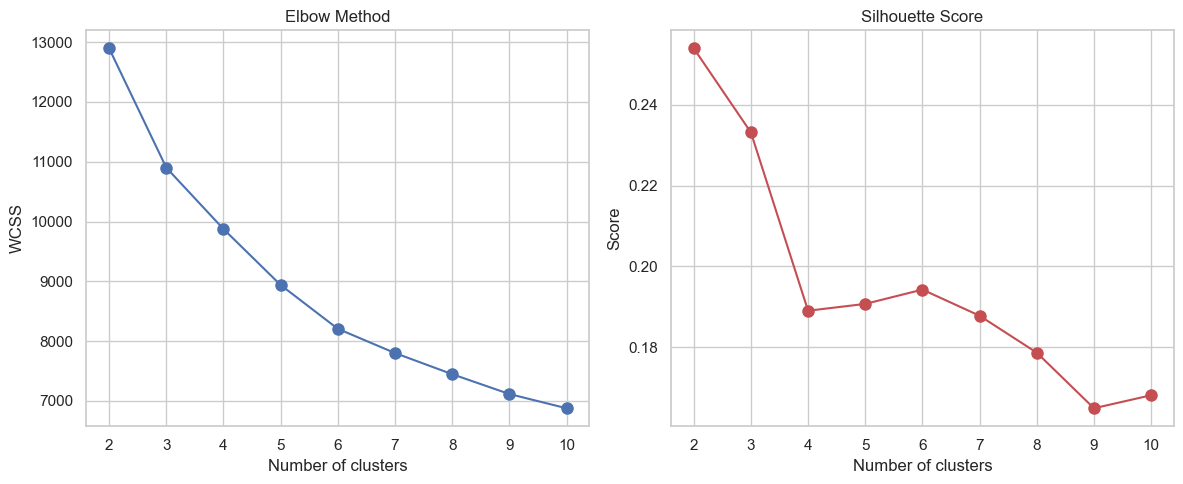

In [30]:
cluster_evaluation = evaluate_clusters(
    stats_scaled,
    max_k=config.max_clusters,
    random_seed=config.random_seed,
    n_init=config.kmeans_n_init,
)

best_silhouette_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["silhouette_score"].idxmax(),
        "k",
    ]
)

print(f"Best k by silhouette for 2022/23: {best_silhouette_k}")
display(cluster_evaluation.round(4))
plot_cluster_evaluation(cluster_evaluation)

### Standalone `k = 2` Clustering
The silhouette table selects `k = 2` as the strongest standalone split for the 2022/23 data. This model is useful for understanding the season on its own, while the later `k = 3` model is retained for direct comparison with the 2021/22 reproduction.

In [31]:
kmeans_k2 = fit_kmeans(
    stats_scaled,
    n_clusters=best_silhouette_k,
    random_seed=config.random_seed,
    n_init=config.kmeans_n_init,
)

reduced_stats_k2 = add_cluster_labels(reduced_stats, kmeans_k2.labels_)

print("Cluster sizes for k = 2:")
display(reduced_stats_k2["Cluster"].value_counts().sort_index().to_frame("players"))

Cluster sizes for k = 2:


,players
Cluster,
0,631
1,1430


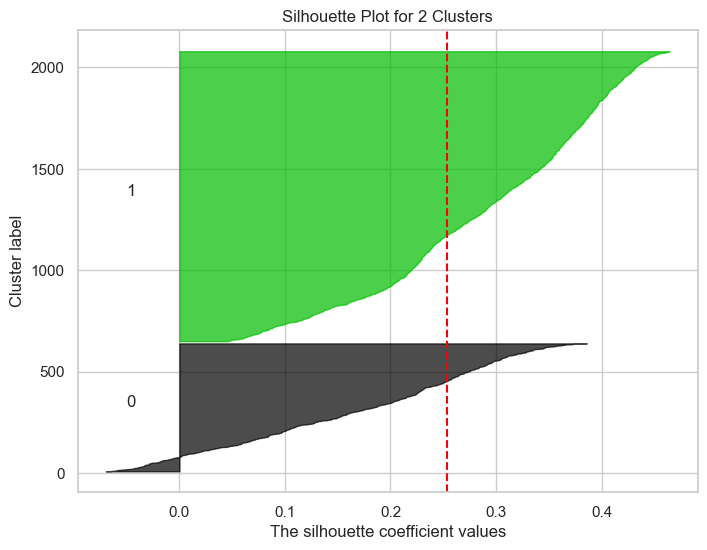

Average Silhouette Width: 0.25


In [32]:
avg_silhouette_k2 = plot_silhouette_profile(
    stats_scaled,
    kmeans_k2.labels_,
    best_silhouette_k,
)

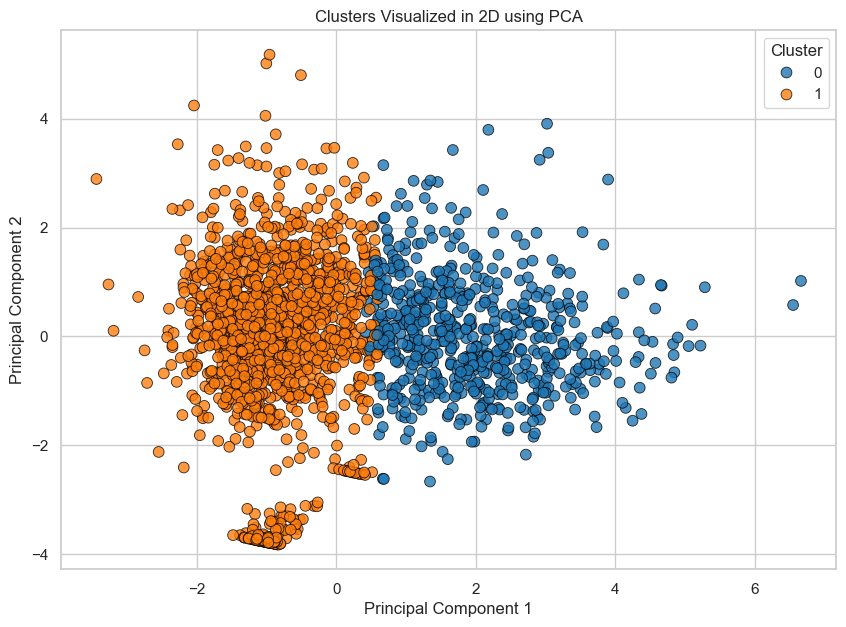

In [33]:
reduced_stats_k2 = add_pca_components(reduced_stats_k2, stats_scaled)
plot_pca_clusters(reduced_stats_k2)

#### `k = 2` Cluster Interpretation
The `k = 2` solution gives the clearest standalone split for 2022/23.

- **Cluster 0** is the broader ball-involvement and defensive-work group. It has lower shot volume (`Shots` around 0.71) but much higher passing activity (`PasTotAtt` around 49), stronger tackling/blocking involvement, and higher aerial success. This cluster likely mixes defenders, midfielders, and lower-shot role players.
- **Cluster 1** is the attacking-output group. It has much higher shot volume (`Shots` around 2.32), more assists, more offsides, and lower passing volume. This profile fits players whose contribution is more directly tied to final-third attacking actions.

This split is statistically stronger than the `k = 3` version by silhouette score, but it is intentionally coarse: it mainly separates attackers from everyone else.

### Comparison `k = 3` Clustering
The following model keeps `k = 3` from the 2021/22 notebook. This is not the best silhouette choice for 2022/23, but it makes the cluster means easier to compare against the previous season.

In [34]:
kmeans_final = fit_kmeans(
    stats_scaled,
    n_clusters=config.optimal_k,
    random_seed=config.random_seed,
    n_init=config.kmeans_n_init,
)

reduced_stats = add_cluster_labels(reduced_stats, kmeans_final.labels_)

## Evaluation and Interpretation
We inspect the fixed `k = 3` comparison model with the same silhouette profile and PCA projection used in 2021/22. The standalone `k = 2` model above has the stronger silhouette result for 2022/23, so these `k = 3` results should be read as a cross-season comparison rather than the strongest data-driven partition for this season.

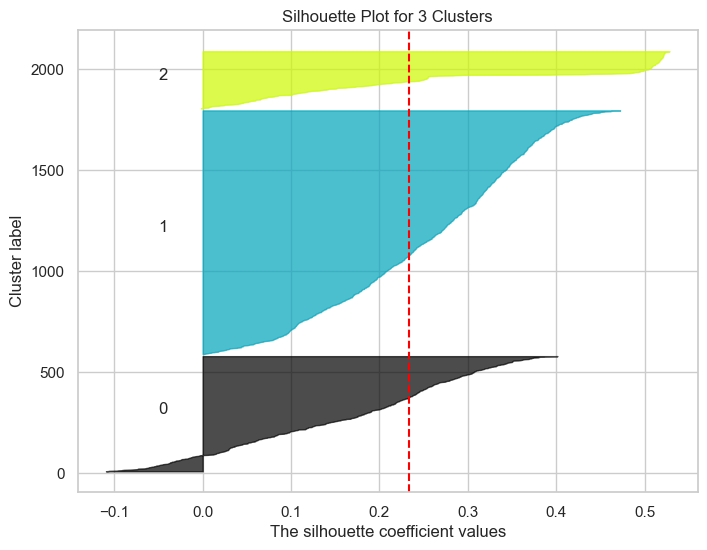

Average Silhouette Width: 0.23


In [35]:
avg_silhouette = plot_silhouette_profile(
    stats_scaled,
    kmeans_final.labels_,
    config.optimal_k,
)